##**1. Datos**

El data set es sacado de la European Social Survey del año 2024.
Lo primero se sube y se lee el archivo.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import sys
import importlib

In [27]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Carga del dataset**

In [28]:
ruta_df = "/content/drive/MyDrive/TFM/Datafile-subset.csv"

df_raw = pd.read_csv(ruta_df)

df = df_raw.copy()

/tmp/ipykernel_727/1128491149.py:3: DtypeWarning: Columns (43) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(ruta_df)


**Carga del codebook**

In [29]:
with open("/content/drive/MyDrive/TFM/Datafile-subset codebook.html", "r", encoding="utf-8") as f:
    soup = BeautifulSoup(f, "html.parser")
print(soup.title.text)


        Codebook
    


**Carga de tabla de variables**

Tabla diccionario creada a partir de los datos del codebook como un resumen de las variables que componen el dataset.  

In [30]:
ruta_diccionario="/content/drive/MyDrive/TFM/Diccionario variables ESS.xlsx"

diccionario = pd.read_excel(ruta_diccionario)

display(diccionario)

,Variable,Nombre,Descripción práctica
0,name,Nombre del dataset,Título del conjunto de datos de procedencia.
1,essround,Ronda ESS,Ronda de la European Social Survey a la que pe...
2,edition,Edición,Versión o edición del archivo de datos utilizado.
3,proddate,Fecha de producción,Fecha de producción de la versión del conjunto...
4,idno,Identificador,Número identificativo del participante dentro ...
5,cntry,País,País en el que se realizó la encuesta.
6,dweight,Peso de diseño,Ponderación que corrige las distintas probabil...
7,pspwght,Peso de postestratificación,Ponderación de postestratificación que incorpo...
8,pweight,Peso poblacional,Ajuste relacionado con el tamaño de la poblaci...
9,anweight,Peso de análisis,Ponderación destinada al análisis de los datos.


**Importamos el menú misfunciones.py**

Se realiza este paso para tener el notebook más limpio y con menos códigos.

In [31]:
# Ruta donde está guardado misfunciones.py
ruta_tfm = "/content/drive/MyDrive/TFM"

# Añadir la carpeta al path de Python
if ruta_tfm not in sys.path:
    sys.path.append(ruta_tfm)

# Importar y actualizar el archivo de funciones
import misfunciones
importlib.reload(misfunciones)

print("misfunciones.py cargado correctamente")

misfunciones.py cargado correctamente


##**2. Visualización de los datos**

Echamos un vistazo a los datos, a ver qué variables tiene el data set, cómo se presenta el archivo.

In [32]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 540671
Columnas: 53


Este data set está formado por 540.671 filas y 53 columnas.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540671 entries, 0 to 540670
Data columns (total 53 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   name      540671 non-null  object 
 1   essround  540671 non-null  int64  
 2   edition   540671 non-null  float64
 3   proddate  540671 non-null  object 
 4   idno      540671 non-null  int64  
 5   cntry     540671 non-null  object 
 6   dweight   540671 non-null  float64
 7   pspwght   540671 non-null  float64
 8   pweight   540671 non-null  float64
 9   anweight  450134 non-null  float64
 10  prob      159320 non-null  float64
 11  stratum   159320 non-null  float64
 12  psu       159320 non-null  float64
 13  happy     540671 non-null  int64  
 14  health    540671 non-null  int64  
 15  hlthhmp   540671 non-null  int64  
 16  inprdsc   298565 non-null  float64
 17  sclmeet   540671 non-null  int64  
 18  gndr      540671 non-null  int64  
 19  yrbrn     540671 non-null  int64  
 20  edul

In [34]:
df.columns.tolist()

['name',
 'essround',
 'edition',
 'proddate',
 'idno',
 'cntry',
 'dweight',
 'pspwght',
 'pweight',
 'anweight',
 'prob',
 'stratum',
 'psu',
 'happy',
 'health',
 'hlthhmp',
 'inprdsc',
 'sclmeet',
 'gndr',
 'yrbrn',
 'edulvla',
 'emplrel',
 'hincfel',
 'hinctnt',
 'impdiff',
 'impenv',
 'impfree',
 'impfun',
 'imprich',
 'impsafe',
 'imptrad',
 'ipadvnt',
 'ipbhprp',
 'ipcrtiv',
 'ipeqopt',
 'ipfrule',
 'ipgdtim',
 'iphlppl',
 'iplylfr',
 'ipmodst',
 'ipshabt',
 'ipsuces',
 'ipudrst',
 'region',
 'actvgrs',
 'clmrlx',
 'dfcnswk',
 'frshrst',
 'gdsprt',
 'grspay',
 'hlpcowk',
 'hlthrwk',
 'hwkstrs']

**Tabla de auditoría**

Vamos a ver las variables y su tipo, los valores únicos y los missings, es decir, hacemos una primera auditoria de los datos.

In [35]:
auditoria = pd.DataFrame({
    "variable": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "n_unicos": df.nunique(dropna=True).values,
    "n_missing": df.isna().sum().values,
    "pct_missing": (df.isna().mean().values * 100).round(2)
})

auditoria.sort_values("pct_missing", ascending=False)

,variable,tipo,n_unicos,n_missing,pct_missing
46,dfcnswk,float64,10,493134,91.21
49,grspay,float64,2477,493134,91.21
52,hwkstrs,float64,9,493134,91.21
47,frshrst,float64,9,493134,91.21
48,gdsprt,float64,9,440676,81.51
44,actvgrs,float64,9,440676,81.51
50,hlpcowk,float64,8,440676,81.51
45,clmrlx,float64,9,440676,81.51
51,hlthrwk,float64,8,440676,81.51
23,hinctnt,float64,15,422066,78.06


**Variable "essround"**

Llama la atención la variable *essround*, lo que puede indicar que el data set no corresponde a una sola encuenta realizada en un año en concreto, sino que contiene observaciones de diferentes rondas de la ESS. Lo que se trata de averiguar a continuación es ver de cuántas rondas está formado el data set y si están las mismas variables, países y coberturas a lo largo de las distintas rondas.



In [36]:
df["essround"].value_counts().sort_index()

,count
essround,
1,42359
2,47537
3,43000
4,56752
5,52458
6,54673
7,40185
8,44387
9,49519


**Análisis de la cobertura de variables por ronda**

El conjunto de datos integra información procedente de 11 rondas de la ESS. Dado que la participación de los países y el contenido de los cuestionarios pueden variar entre rondas, un porcentaje elevado de valores ausentes no implica necesariamente un problema de calidad de los datos, sino que puede deberse a que determinadas variables únicamente fueron recogidas en algunas ediciones de la encuesta.

Por este motivo, antes de tomar decisiones sobre la eliminación o selección de variables, se analiza su porcentaje de disponibilidad en cada ronda. Este análisis permitirá distinguir entre variables con valores ausentes dentro de las rondas en las que fueron recogidas y variables cuya menor cobertura se debe a su ausencia en determinadas ediciones del ESS.


In [37]:
cobertura_ronda = (
    df.groupby("essround")
      .agg({
          col: lambda x: round(x.notna().mean() * 100, 1)
          for col in df.columns
      })
      .T
)

cobertura_ronda

essround,1,2,3,4,5,6,7,8,9,10,11
name,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
essround,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
edition,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
proddate,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
idno,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
cntry,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
dweight,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
pspwght,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
pweight,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
anweight,100.0,0.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


**Interpretación de la cobertura por ronda**

Al analizar las variables por ronda, se observa que no todas están disponibles durante todo el periodo estudiado. Algunas de las variables principales, como happy, health, hlthhmp, sclmeet, gndr o yrbrn, aparecen en las once rondas, mientras que otras solo se incluyeron en determinados años.

Esto explica por qué algunas variables presentaban inicialmente porcentajes muy altos de valores ausentes. Por ejemplo, hwkstrs tenía un 91,21 % de valores missing, pero al analizarla por ronda vemos que está disponible al 100 % en la ronda 2 y no aparece en las demás. Por tanto, en este caso el elevado porcentaje de valores ausentes no se debe a una mala calidad de los datos, sino a que la pregunta solo se incluyó en una ronda concreta.

##**3. Revisión de los valores únicos y códigos especiales**

Una vez analizada la cobertura de las variables por ronda, el siguiente paso consiste en revisar los valores que toma cada variable. El objetivo es comprobar si, además de las categorías válidas, existen códigos especiales utilizados por la ESS para representar respuestas no válidas o situaciones específicas, como *don't know, refusal*, entre otros

Esta comprobación es necesaria porque estos códigos pueden aparecer como valores numéricos y, por tanto, Pandas no los identifica automáticamente como valores ausentes (NaN). Antes de realizar cualquier proceso de limpieza, es necesario identificarlos y comprobar su significado en la documentación de la ESS.

Este análisis será importante a la hora de seleccionar las variables, ya que habrá que encontrar un equilibrio entre mantener una muestra amplia, utilizando varias rondas, e incorporar variables más específicas, aunque estén disponibles en un número menor de ellas.


In [38]:
for col in df.columns:
    print(f"\n{'='*60}")
    print(col.upper())
    print(f"{'='*60}")

    print("Número de valores únicos:", df[col].nunique(dropna=False))

    if df[col].nunique(dropna=False) <= 30:
        print(df[col].value_counts(dropna=False).sort_index())


NAME
Número de valores únicos: 12
name
ESS10SCe03_2    22074
ESS10e03_3      37611
ESS11e04_1      50116
ESS1e06_7       42359
ESS2e03_6       47537
ESS3e03_7       43000
ESS4e04_6       56752
ESS5e03_6       52458
ESS6e02_7       54673
ESS7e02_3       40185
ESS8e02_3       44387
ESS9e03_3       49519
Name: count, dtype: int64

ESSROUND
Número de valores únicos: 11
essround
1     42359
2     47537
3     43000
4     56752
5     52458
6     54673
7     40185
8     44387
9     49519
10    59685
11    50116
Name: count, dtype: int64

EDITION
Número de valores únicos: 9
edition
2.3    84572
2.7    54673
3.2    22074
3.3    87130
3.6    99995
3.7    43000
4.1    50116
4.6    56752
6.7    42359
Name: count, dtype: int64

PRODDATE
Número de valores únicos: 8
proddate
01.12.2018     90537
02.12.2025     37611
09.12.2025     22074
12.01.2026     50116
14.11.2023     56752
18.08.2025    107131
23.11.2023    126931
26.01.2026     49519
Name: count, dtype: int64

IDNO
Número de valores únicos: 155

Lo que se pretende es recorrer todas las variables del dataset para comprobar cuántos valores diferentes contienen cada una. En aquellas con un número reducido de categorías, se muestran además la frecuencia de cada valor. El objetivo era identificar posibles códigos especiales de respuesta que Pandas no estuviera reconociendo como valores ausentes. Se limita la visualización a variables con un máximo de 30 valores diferentes simplemente para evitar salidas demasiado extensas en variables como identificadores o variables continuas.

**Identificación de los códigos especiales de respuesta**

La revisión anterior de los valores únicos ha mostrado que algunas variables contienen códigos que se encuentran fuera de su escala habitual. Estos valores pueden corresponder a categorías especiales de respuesta, como respuestas no disponibles, rechazo a contestar u otras situaciones contempladas en el cuestionario.

Antes de realizar cualquier transformación, es necesario consultar la documentación de la ESS para identificar correctamente estos códigos. De esta forma se evita considerar como información válida valores que realmente representan ausencia de respuesta.

Desde el menú de mis funciones (misfunciones.py) analizo los valores que pueden ser missing de las variables:

In [39]:
import sys

sys.path.append("/content/drive/MyDrive/TFM")

from misfunciones import extraer_cod_missing

In [40]:
cod_missing = extraer_cod_missing(soup, df.columns)

cod_missing

{'dweight': ['77', '88', '99'],
 'pspwght': ['77', '88', '99'],
 'pweight': ['77', '88', '99'],
 'anweight': ['77', '88', '99'],
 'prob': ['77', '88', '99'],
 'stratum': ['77', '88', '99'],
 'psu': ['77', '88', '99'],
 'happy': ['77', '88', '99'],
 'health': ['7', '8', '9'],
 'hlthhmp': ['7', '8', '9'],
 'inprdsc': ['77', '88', '99'],
 'sclmeet': ['77', '88', '99'],
 'gndr': ['9'],
 'yrbrn': ['7777', '8888', '9999'],
 'edulvla': ['77', '88', '99'],
 'emplrel': ['6', '7', '8', '9'],
 'hincfel': ['7', '8', '9'],
 'hinctnt': ['77', '88', '99'],
 'impdiff': ['7', '8', '9'],
 'impenv': ['7', '8', '9'],
 'impfree': ['7', '8', '9'],
 'impfun': ['7', '8', '9'],
 'imprich': ['7', '8', '9'],
 'impsafe': ['7', '8', '9'],
 'imptrad': ['7', '8', '9'],
 'ipadvnt': ['7', '8', '9'],
 'ipbhprp': ['7', '8', '9'],
 'ipcrtiv': ['7', '8', '9'],
 'ipeqopt': ['7', '8', '9'],
 'ipfrule': ['7', '8', '9'],
 'ipgdtim': ['7', '8', '9'],
 'iphlppl': ['7', '8', '9'],
 'iplylfr': ['7', '8', '9'],
 'ipmodst': ['7', '

La extracción del codebook permite identificar los códigos que la ESS considera valores perdidos para cada variable. Se observa que estos códigos no son iguales en todas las variables. Por este motivo, la recodificación deberá realizarse de forma específica para cada variable.

Antes de sustituir estos códigos por valores ausentes (NaN), se comprobará cuáles de ellos aparecen realmente en el conjunto de datos y con qué frecuencia.

In [41]:
#Cod reales del df y su frecuencia:
resultado_cod = misfunciones.comprobar_cod_missing(
    df,
    cod_missing
)

resultado_cod

,variable,codigo,frecuencia,porcentaje
0,stratum,77,46,0.009
1,stratum,88,52,0.010
2,stratum,99,80,0.015
3,psu,77,7,0.001
4,psu,88,7,0.001
...,...,...,...,...
122,hlthrwk,9,682,0.126
123,hwkstrs,6,5558,1.028
124,hwkstrs,7,66,0.012
125,hwkstrs,8,667,0.123


In [42]:
#Agrupar por variables:
resumen_cod = (
    resultado_cod
    .groupby("variable", as_index=False)
    .agg(
        n_codigos_especiales=("frecuencia", "sum")
    )
)

resumen_cod.head()

,variable,n_codigos_especiales
0,actvgrs,542
1,clmrlx,503
2,dfcnswk,28219
3,edulvla,754
4,emplrel,58704


Se agrupan los resultados por variable y se suman las frecuencias de todos los códigos especiales detectados en cada una, ya que una misma variable puede tener varios códigos especiales de respuesta. De esta forma, se obtiene el número total de observaciones que presentan algún código especial para cada variable para, así, facilitar su análisis.

Además de querer ver cuáles son los caracteres especiales para cada variable, interesa saber qué tipo de interpretación tiene:

In [43]:
tabla_cod_missing = misfunciones.asociar_tipo_cod_missing(
    soup,
    cod_missing
)

display(tabla_cod_missing)

,variable,codigo,tipo_respuesta
0,dweight,77,Refusal
1,dweight,88,Don't know
2,dweight,99,No answer
3,pspwght,77,Refusal
4,pspwght,88,Don't know
...,...,...,...
138,hlthrwk,9,No answer
139,hwkstrs,6,Not applicable
140,hwkstrs,7,Refusal
141,hwkstrs,8,Don't know


Como se observa, por ejemplo, parala variable *dweight*, el código 77 está asociado a una respuesta de *Refusal*, el 88 a *Don`t know*, el 99 a *No answer* y así sucesivamente. Sin embargo, como se ha visto antes y en esta tambla tmabién, cada variable tiene su propio código, que alguans veces coinidirá con otras variables.

In [44]:
for i, fila in resumen_cod.iterrows():

    variable = fila["variable"]

    n_disponibles = df[variable].notna().sum()

    resumen_cod.loc[i, "n_disponibles"] = n_disponibles
    resumen_cod.loc[i, "pct_codigos_especiales"] = (
        fila["n_codigos_especiales"] / n_disponibles * 100
    )

resumen_cod = resumen_cod.sort_values(
    "pct_codigos_especiales",
    ascending=False
)

resumen_cod.head(15)

,variable,n_codigos_especiales,n_disponibles,pct_codigos_especiales
8,grspay,34577,47537.0,72.737026
13,hlpcowk,61091,99995.0,61.094055
15,hlthrwk,61013,99995.0,61.016051
2,dfcnswk,28219,47537.0,59.362181
12,hinctnt,26428,118605.0,22.282366
16,hwkstrs,7428,47537.0,15.625723
4,emplrel,58704,537367.0,10.924378
29,ipfrule,12955,462494.0,2.801117
35,ipsuces,11998,462489.0,2.594224
30,ipgdtim,11827,462488.0,2.557256


Una vez identificados los códigos especiales definidos en el codebook de la ESS, se comprobó cuáles de ellos aparecen realmente en el conjunto de datos y con qué frecuencia. A continuación, se agruparon estos códigos por variable para conocer su peso sobre las observaciones disponibles. Para calcular este porcentaje se utilizó como referencia el número de registros en los que cada variable está disponible, en lugar del tamaño total del dataset, ya que el análisis previo mostró que algunas variables únicamente fueron recogidas en determinadas rondas. Así se obtiene una visión más realista de la presencia de respuestas especiales y se detecta aquellas variables que requieren una revisión más detallada antes de iniciar la limpieza de los datos.

A continuación se pintan los valores especiales para tener una idea más visual de estos resultados.

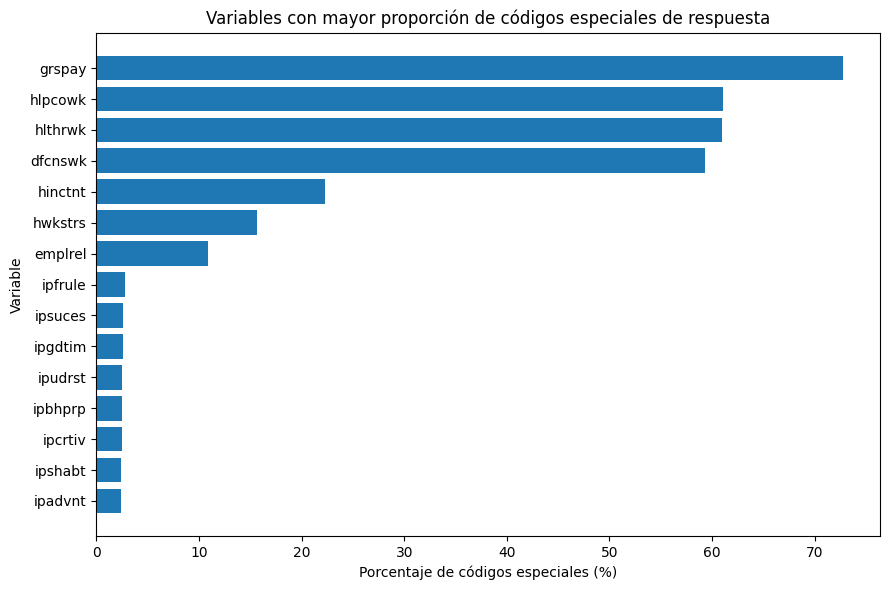

In [45]:
import matplotlib.pyplot as plt

top15 = resumen_cod.head(15).sort_values(
    "pct_codigos_especiales"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top15["variable"],
    top15["pct_codigos_especiales"]
)

plt.xlabel("Porcentaje de códigos especiales (%)")
plt.ylabel("Variable")
plt.title("Variables con mayor proporción de códigos especiales de respuesta")

plt.tight_layout()
plt.show()

La representación muestra diferencias importantes en la presencia de códigos especiales entre las variables analizadas. Destacan especialmente *grspay, hlpcowk, hlthrwk y dfcnswk*, donde estos códigos representan aproximadamente entre el 59 % y el 73 % de las observaciones disponibles. En un segundo nivel se encuentran *hinctnt, hwkstrs y emplrel*, mientras que en el resto de las variables representadas su peso es considerablemente menor. Estos resultados permiten identificar las variables que requieren una revisión más detallada antes de realizar la limpieza, ya que una elevada presencia de códigos especiales no implica necesariamente datos ausentes en sentido estricto, sino que puede incluir categorías como respuestas no aplicables, rechazo o desconocimiento.

Tras identificar las variables con mayor proporción de códigos especiales, se analiza la distribución de estos códigos de forma individual. Esta revisión permite distinguir entre la ausencia de respuesta propiamente dicha, como rechazo, desconocimiento o falta de respuesta, y aquellas observaciones clasificadas como *Not applicable*. Esta distinción es relevante, ya que una elevada proporción de códigos especiales no implica necesariamente un problema de calidad de los datos, sino que puede deberse al diseño o a las condiciones de aplicación de determinadas preguntas.

In [46]:
tabla_cod_real = resultado_cod.merge(
    tabla_cod_missing,
    on=["variable", "codigo"],
    how="left"
)

display(tabla_cod_real)

,variable,codigo,frecuencia,porcentaje,tipo_respuesta
0,stratum,77,46,0.009,Refusal
1,stratum,88,52,0.010,Don't know
2,stratum,99,80,0.015,No answer
3,psu,77,7,0.001,Refusal
4,psu,88,7,0.001,Don't know
...,...,...,...,...,...
122,hlthrwk,9,682,0.126,No answer
123,hwkstrs,6,5558,1.028,Not applicable
124,hwkstrs,7,66,0.012,Refusal
125,hwkstrs,8,667,0.123,Don't know


In [47]:
variables_revision = [
    "grspay",
    "hlpcowk",
    "hlthrwk",
    "dfcnswk",
    "hinctnt",
    "hwkstrs",
    "emplrel"
]

graf_cod = tabla_cod_real[
    tabla_cod_real["variable"].isin(
        variables_revision
    )
].copy()

In [48]:
graf_cod = graf_cod.pivot_table(
    index="variable",
    columns="tipo_respuesta",
    values="frecuencia",
    aggfunc="sum",
    fill_value=0
)

graf_cod_pct = (
    graf_cod
    .div(graf_cod.sum(axis=1), axis=0)
    * 100
)

display(graf_cod_pct)

tipo_respuesta,Don't know,No answer,Not applicable,Refusal
variable,,,,
dfcnswk,1.545058,3.238952,95.120309,0.095680
emplrel,2.437653,8.173208,87.762333,1.626806
grspay,6.032912,2.362842,81.030743,10.573503
hinctnt,41.433328,3.413047,0.000000,55.153625
hlpcowk,0.784076,1.137647,98.024259,0.054018
hlthrwk,0.686739,1.117795,98.149575,0.045892
hwkstrs,8.979537,15.306947,74.824987,0.888530


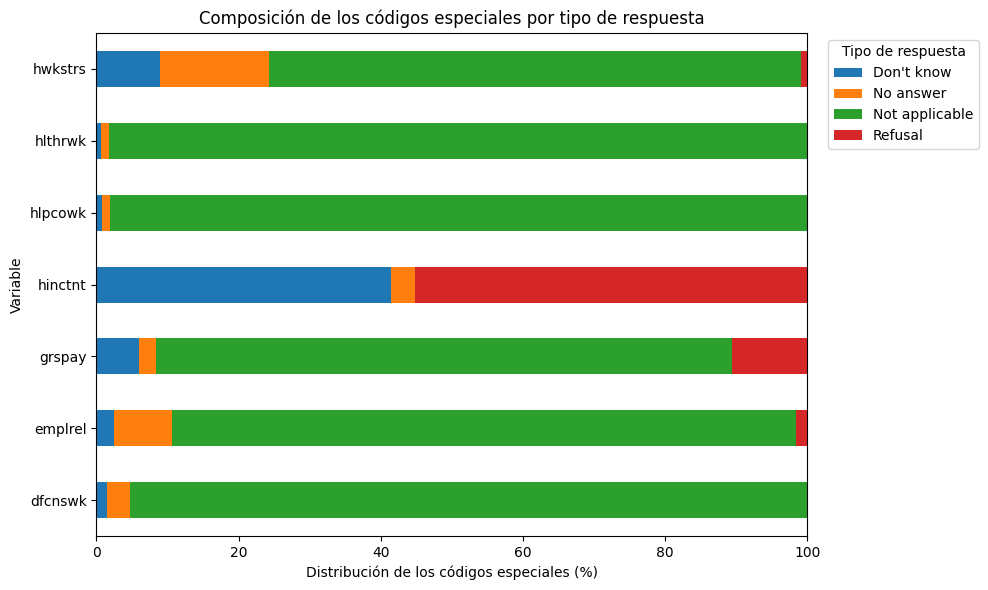

In [49]:
import matplotlib.pyplot as plt

graf_cod_pct.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Distribución de los códigos especiales (%)")
plt.ylabel("Variable")
plt.title(
    "Composición de los códigos especiales "
    "por tipo de respuesta"
)

plt.legend(
    title="Tipo de respuesta",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

La clasificación de los códigos especiales según el tipo de respuesta permite observar diferencias claras entre las variables analizadas. En variables como *hlpcowk, hlthrwk y dfcnswk*, la mayor parte de estos códigos corresponde a situaciones clasificadas como *Not applicable*, lo que indica que su elevada presencia está principalmente relacionada con las condiciones de aplicación de las preguntas y no con la falta de respuesta de los participantes. Un comportamiento diferente se observa en *hinctnt*, donde predominan las categorías *Refusal y Don't know*. Por tanto, el origen de los valores no válidos no es homogéneo entre las variables, aspecto que deberá tenerse en cuenta en las decisiones posteriores de limpieza y selección.

Ahora y, antes de iniciar la recodificación de los valores especiales, se revisan de forma individual aquellas variables cuyo comportamiento requiere una interpretación adicional. En particular, se consulta directamente el codebook para comprobar el significado de las categorías de *emplrel* y evitar interpretar los códigos únicamente a partir de su valor numérico. Esta comprobación permite distinguir correctamente entre categorías válidas, situaciones no aplicables y respuestas consideradas ausentes por la ESS.

In [50]:
# Revisamos directamente las categorías de emplrel en el codebook

seccion = soup.find("h3", id="emplrel")
tabla = seccion.find_next("table")

datos_emplrel = []

for fila in tabla.find_all("tr")[1:]:

    celdas = fila.find_all("td")

    if len(celdas) >= 2:
        datos_emplrel.append({
            "codigo": celdas[0].get_text(strip=True),
            "respuesta": celdas[1].get_text(strip=True)
        })

tabla_emplrel = pd.DataFrame(datos_emplrel)

display(tabla_emplrel)

,codigo,respuesta
0,1,Employee
1,2,Self-employed
2,3,Working for own family business
3,6,Not applicable*
4,7,Refusal*
5,8,Don't know*
6,9,No answer*


La revisión específica de emplrel confirma que el código 6 corresponde a la categoría Not applicable, mientras que los códigos 7, 8 y 9 representan Refusal, Don't know y No answer, respectivamente. Por tanto, la elevada frecuencia observada para el código 6 no debe interpretarse como falta de respuesta, sino principalmente como consecuencia de la aplicabilidad de la pregunta. Esta comprobación refuerza la necesidad de considerar el significado de los códigos especiales antes de proceder a su tratamiento como valores ausentes.